In [ ]:
i = []
while True:
  i.append(1)

In [1]:
!pip install rioxarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 44.6 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [2]:
!pip install --upgrade xee

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 477.1/477.1 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 76.0 MB/s eta 0:00:00
  Attempting uninstall: earthengine-api
    Found existing installation: earthengine-api 1.5.24
    Uninstalling earthengine-api-1.5.24:
      Successfully uninstalled earthengine-api-1.5.24


In [3]:
!pip install -U geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 54.6 MB/s eta 0:00:00
  Attempting uninstall: geemap
    Found existing installation: geemap 0.35.3
    Uninstalling geemap-0.35.3:
      Successfully uninstalled geemap-0.35.3


In [4]:
!pip install geopandas

In [5]:
!pip install seaborn

In [6]:
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray
import xee
import numpy as np
import matplotlib.pyplot as plt
import geemap
import rioxarray as xr
import seaborn as sns
import ee

In [7]:
ee.Authenticate()
ee.Initialize(project = "ee-grmntfrancis0",
             opt_url='https://earthengine-highvolume.googleapis.com')

In [8]:
map = geemap.Map()
map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [9]:
roi = map.draw_last_feature.geometry()
roi

ee.Geometry({
  "functionInvocationValue": {
    "functionName": "Feature.geometry",
    "arguments": {
      "feature": {
        "functionInvocationValue": {
          "functionName": "Feature",
          "arguments": {
            "geometry": {
              "functionInvocationValue": {
                "functionName": "GeometryConstructors.Point",
                "arguments": {
                  "coordinates": {
                    "constantValue": [
                      30.27832,
                      6.577303
                    ]
                  }
                }
              }
            }
          }
        }
      }
    }
  }
})

In [10]:
border = ee.FeatureCollection("FAO/GAUL_SIMPLIFIED_500m/2015/level0").filterBounds(roi)

In [11]:
map.addLayer(border, {}, "border")

In [12]:
vec = geemap.ee_to_gdf(border)
vec

,geometry,ADM0_CODE,ADM0_NAME,DISP_AREA,EXP0_YEAR,STATUS,STR0_YEAR,Shape_Area,Shape_Leng
0,GEOMETRYCOLLECTION (LINESTRING (24.59776 9.369...,74,South Sudan,NO,3000,Member State,2011,51.599166,46.905431


In [13]:
era5 = ee.ImageCollection("ECMWF/ERA5/DAILY").filterDate("1986", "2025").select("mean_2m_air_temperature")
era5

In [14]:
!pip install cdsapi

import cdsapi
import os

In [16]:
import xarray as xr

In [17]:
from jinja2.nodes import ExprStmt
ds = xr.open_dataset(
    era5,
    engine = "ee",
    crs = "EPSG: 4326",
    geometry = border.geometry(),
    scale = 0.01
)
ds

<xarray.Dataset> Size: 52GB
Dimensions:                  (time: 12609, lon: 1180, lat: 875)
Coordinates:
  * time                     (time) datetime64[ns] 101kB 1986-01-01 ... 2020-...
  * lon                      (lon) float64 9kB 24.16 24.17 24.18 ... 35.94 35.95
  * lat                      (lat) float64 7kB 3.493 3.503 3.513 ... 12.22 12.23
Data variables:
    mean_2m_air_temperature  (time, lon, lat) float32 52GB ...
Attributes: (12/36)
    date_range:               [284083200000, 1594252800000]
    description:              <p>ERA5 is the fifth generation ECMWF atmospher...
    keywords:                 ['climate', 'copernicus', 'dewpoint', 'ecmwf', ...
    max_mirrored_version:     1594797432309553
    period:                   1
    period_mapping:           [284083200000, 1594252800000]
    ...                       ...
    visualization_3_bands:    u_component_of_wind_10m
    visualization_3_max:      30.0
    visualization_3_min:      0.0
    visualization_3_name:     Daily mean u-component of wind at 10m
    visualization_3_palette:  #FFFFFF,#FFFF71,#DEFF00,#9EFF00,#77B038,#007E55...
    crs:                      EPSG: 4326

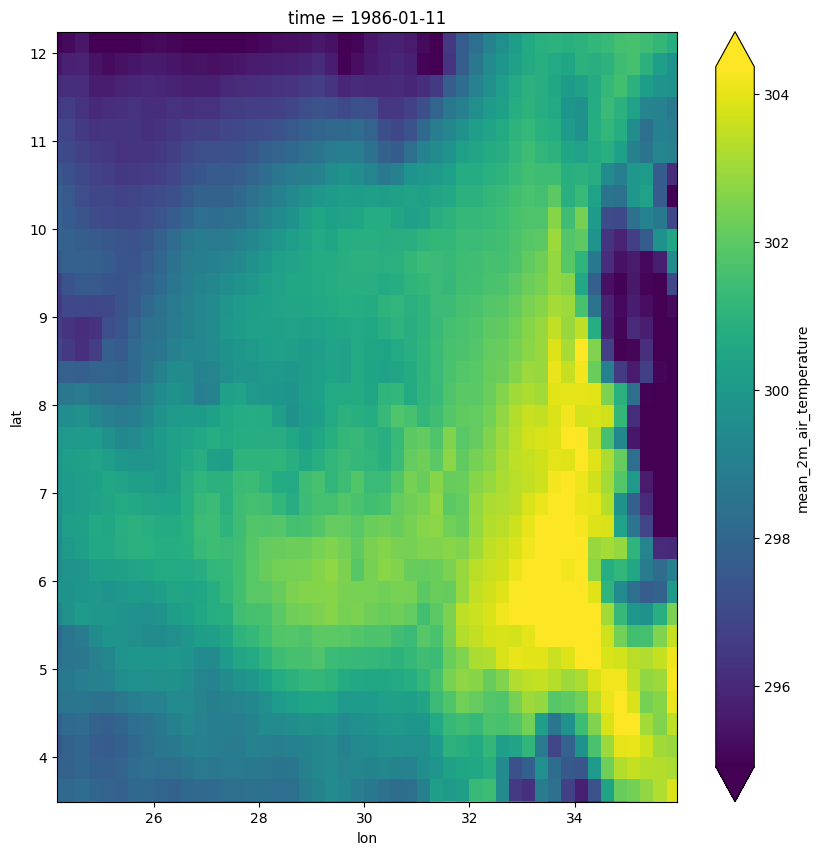

In [18]:
ds.isel(time = 10).mean_2m_air_temperature.plot(
    x = "lon",
    y = "lat",
    robust = True,
    figsize = (10, 10)
)

In [19]:
import geopandas as pgd

In [20]:
vec.plot

In [21]:
vec.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [22]:
vec.geometry

,geometry
0,GEOMETRYCOLLECTION (LINESTRING (24.59776 9.369...


In [24]:
import rioxarray as rxr

In [25]:
import pandas as pd

In [ ]:
ds_rename = ds.rename({"lon": "x", "lat":"y"})
ds_clip = ds_rename.rio.clip(vec.geometry, vec.crs)

In [2]:
ds_clip.isel(time = 10).mean_2m_air_temperature.plot.contourf(
    x = "x",
    y = "y",
    robust = True,
    levels = 20,
    cmap = "coolwarm"
)
plt.tight_layout(rect=[0.02, 0.05, 0.098, 0.95])
plt.gca().set_aspect("equal")
plt.show()

NameError: name 'ds_clip' is not defined

In [ ]:
ds_clip["mean_2m_air_temperature_celsius"] = ds_clip["mean_2m_air_temperature"] - 273.15

In [ ]:
import pandas as pd

In [ ]:
ds_clip.isel(time = 10).mean_2m_air_temperature_celsius.plot.contourf(
    x = "x",
    y = "y",
    robust = True,
    levels = 20,
    cmap = "viridis"
)
plt.tight_layout(rect=[0.02, 0.05, 0.098, 0.95])
plt.gca().set_aspect("equal")
plt.show()